# Attendance

[The link to SEAts](https://gold.seats.cloud/angular/#/lectures)

# 15 Language models and the Transformer

In [77]:
import os
import re
import sys
import random
import shutil
import string
import pathlib

import numpy as np
np.set_printoptions(linewidth=150)

import tensorflow as tf

import matplotlib.pyplot as plt

from IPython.core.magic import register_cell_magic
from IPython.display import clear_output

os.environ["KERAS_BACKEND"] = "jax"

import keras
import keras_hub

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [21]:
# a custom callback that prints training stats without cluttering the notebook
# ported and expanded from lectures/04/chapter05_fundamentals-of-ml
# and see: https://chatgpt.com/share/69aeecc7-bb80-8005-a441-80e4cc062606
class PrintStatsCallback(keras.callbacks.Callback):
    def __init__(self, epochs):
        super(keras.callbacks.Callback, self).__init__()
        self.epochs = epochs
        self.current_epoch = 0
        self.total_train_batches = None
        self.total_test_batches = None
    def print_stats(self, batch=None, val_batch=None):
        # print train stats
        tot = self.total_train_batches if self.total_train_batches is not None else "unknown"
        current_batch = batch + 1 if batch is not None else tot
        msg = f"epoch: {self.current_epoch+1}/{self.epochs}"
        fmt = len(str(tot))
        print(f"{msg} |     batch: {current_batch:>{fmt}}/{tot:>{fmt}} | {self._metrics}")
        # print val stats (including past ones for readability)
        if hasattr(self, "_val_metrics"):
            val_tot = self.total_test_batches if self.total_test_batches is not None else "unknown"
            current_val_batch = val_batch + 1 if val_batch is not None else val_tot
            print(f"{' ' * len(msg)} | val batch: {current_val_batch:>{fmt}}/{val_tot:>{fmt}} | {self._val_metrics}")
    def on_train_batch_end(self, batch, logs=None):
        self._max_batch_seen = batch
        clear_output(wait=True)
        self._metrics = " – ".join(f"{k:>{len(k) + 4}}: {v:.4f}" for k, v in logs.items())
        self.print_stats(batch=batch)
    def on_test_batch_end(self, batch, logs=None):
        self._max_test_batch_seen = batch
        clear_output(wait=True)
        self._val_metrics = " – ".join(f"{f'val_{k}':>{len(k) + 4}}: {v:.4f}" for k, v in logs.items())
        self.print_stats(val_batch=batch)
    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch
        self._max_batch_seen = 0
    def on_train_end(self, epoch, logs=None):
        if self.total_train_batches is None:
            self.total_train_batches = self._max_batch_seen + 1
    def on_test_end(self, logs=None):
        if self.total_test_batches is None:
            self.total_test_batches = self._max_test_batch_seen + 1
    def on_train_end(self, logs=None):
        print()

In [3]:
def plot_history(history, metric):
    accuracy = history.history[metric]
    val_accuracy = history.history[f"val_{metric}"]
    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "r--", label=f"Training {metric}")
    plt.plot(epochs, val_accuracy, "b", label=f"Validation {metric}")
    plt.title(f"Training and validation {metric}")
    plt.legend()
    plt.show()

In [4]:
# whether we use our manual implementations, or keras/keras_hub layers
USE_KERAS_IMPL = False

## The Language Model

Skipping the [Shakespeare GRU model](https://deeplearningwithpython.io/chapters/chapter15_language-models-and-the-transformer/#training-a-shakespeare-language-model), since we're going to do this in the Text Generation notebook!

## Sequence-to-Sequence Learning

### The Seq-to-Seq Model

<!-- <img style="height:700px" src="images/nlp/stanford.seq2seq.png"> -->
<img style="height:700px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/nlp/stanford.seq2seq.png">

<small>[Chris Manning, CS224N, Stanford](https://web.stanford.edu/class/cs224n/index.html), [lecture 7](https://web.stanford.edu/class/cs224n/slides/cs224n-2022-lecture07-nmt.pdf)  
The original paper: ["Sequence to Sequence Learning with Neural Networks"](https://arxiv.org/abs/1409.3215)</small>

### English-to-Spanish Translation

In [5]:
MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

DATASET_DIR = pathlib.Path("spa-eng")

if not DATASET_DIR.exists():
    !wget http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
    !unzip -q spa-eng.zip

--2026-03-18 09:29:07--  http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.68.207, 172.217.194.207, 142.250.4.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.68.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2638744 (2.5M) [application/zip]
Saving to: ‘spa-eng.zip’

spa-eng.zip         100%[===================>]   2.52M  1.93MB/s    in 1.3s    

2026-03-18 09:29:08 (1.93 MB/s) - ‘spa-eng.zip’ saved [2638744/2638744]



Other languages available [here](https://www.manythings.org/anki/)!

In [6]:
TEXT_FILE = DATASET_DIR / "spa.txt"

with TEXT_FILE.open() as f:
    lines = f.read().strip().split("\n")

text_pairs = []
# spa.txt is tab separated, but the other datasets use spaces
separator = "\t" if "\t" in lines[0] else " "

for line in lines:
    # for datasets other than the official one, only tak
    english, spanish = line.split(separator)[:2]
    spanish = "[start] " + spanish + " [end]"
    text_pairs.append((english, spanish))

In [7]:
print(random.choice(text_pairs))

('The meeting was canceled.', '[start] La reunión fue cancelada. [end]')


In [8]:
random.seed(42)
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples:num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples:]

#### Vectorizing the English and Spanish text pairs

In [9]:
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", ""
    )

VOCAB_SIZE = 15000
SEQUENCE_LENGTH = 20

english_tokenizer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
)
spanish_tokenizer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH + 1,
    standardize=custom_standardization,
)
train_english_texts = [pair[0] for pair in train_pairs]
train_spanish_texts = [pair[1] for pair in train_pairs]
english_tokenizer.adapt(train_english_texts)
spanish_tokenizer.adapt(train_spanish_texts)

#### Preparing datasets for the translation task

In [10]:
BATCH_SIZE = 64

def format_dataset(eng, spa):
    eng = english_tokenizer(eng)
    spa = spanish_tokenizer(spa)
    # note the -1 and 1: each timestep in the Spanish features
    # 'faces' the next timestep in the labels -> we produce as
    # many predictions as there are timesteps in parallel!
    features = {"english": eng, "spanish": spa[:, :-1]}
    labels = spa[:, 1:]
    # detect masking (0) and assign 0 to masked tokens, 1 to the rest
    # so that we can compute accuracy statistics without
    sample_weights = labels != 0
    return features, labels, sample_weights

def make_dataset(pairs):
    eng_texts, spa_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    spa_texts = list(spa_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).prefetch(16).cache()

train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

##### Test dataset

In [11]:
for inputs, targets, _ in train_ds:
    print(f"inputs['english'].shape: {inputs['english'].shape}, dtype: {inputs['english'].dtype}")
    print(f"inputs['spanish'].shape: {inputs['spanish'].shape}, dtype: {inputs['spanish'].dtype}")
    print(f"targets.shape: {targets.shape}, dtype: {targets.dtype}")
    break

inputs['english'].shape: (64, 20), dtype: <dtype: 'int64'>
inputs['spanish'].shape: (64, 20), dtype: <dtype: 'int64'>
targets.shape: (64, 20), dtype: <dtype: 'int64'>


In [12]:
vocabulary_en = [str(s) for s in english_tokenizer.get_vocabulary()]
vocabulary_spa = [str(s) for s in spanish_tokenizer.get_vocabulary()]
# vocabulary
def detokenize(toks, vocab_list):
    return " ".join([vocab_list[t] for t in toks])

In [13]:
for inputs, _, _ in train_ds:
    # take the first sequence
    eng = inputs["english"][0]
    spa = inputs["spanish"][0]

    print(eng.shape, spa.shape)
    print(detokenize(eng, vocabulary_en))
    print(detokenize(spa, vocabulary_spa))
    break

(20,) (20,)
sea otters love to eat clams while swimming on their backs         
[start] a las [UNK] marinas les encanta comer almejas mientras [UNK] de espaldas [end]      


#### Baseline

In [14]:
# see: https://chatgpt.com/share/69b2a232-8e98-8005-bfe5-91681b20c864
# get all the tokens
labels = tf.concat([labels for _, labels, _ in val_ds], axis=0)
# discard all 0s -> now this is one long tensor with all tokens
labels = tf.boolean_mask(labels, labels != 0)
# turn into bins
counts = tf.math.bincount(labels)
# turn into probs
probs = counts / tf.reduce_sum(counts)

In [15]:
likeliest_class = tf.math.argmax(probs).numpy().item()
prob_likeliest_class = probs[likeliest_class].numpy().item()
print(f"Likeliest class: {likeliest_class}, probability: {prob_likeliest_class} -> accuracy: {prob_likeliest_class * 100:.2f}%")

Likeliest class: 3, probability: 0.14126977832414642 -> accuracy: 14.13%


In [16]:
loss = -tf.reduce_sum(probs * tf.math.log(probs + 1e-9))
print(f"Entropy of the dataset: {loss.numpy().item()}.")

Entropy of the dataset: 5.956715575406663.


---

### Sequence-to-sequence learning with RNNs

#### GRU-based encoder

In [17]:
EMBED_DIM = 256
LATENT_DIM = 1024

source = keras.Input(shape=(None,), dtype="int32", name="english")
x = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(source)
encoded_output = keras.layers.Bidirectional(
    keras.layers.GRU(LATENT_DIM), merge_mode="sum"
)(x)

#### GRU-based decoder and the end-to-end model

In [18]:
past_target = keras.Input(shape=(None,), dtype="int32", name="spanish")
x = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(past_target)
# we return all the timesteps!
rnn_layer = keras.layers.GRU(LATENT_DIM, return_sequences=True)
x = rnn_layer(x, initial_state=encoded_output)
x = keras.layers.Dropout(0.5)(x)
target_predictions = keras.layers.Dense(VOCAB_SIZE, activation="softmax")(x)
seq2seq_rnn = keras.Model([source, past_target], target_predictions)

In [19]:
seq2seq_rnn.summary(line_length=80)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ english (InputLayer)  │ (None, None)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ spanish (InputLayer)  │ (None, None)      │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, None, 256) │   3,840,000 │ english[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ not_equal (NotEqual)  │ (None, None)      │           0 │ english[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding_1           │ (None, None, 256) │   3,840,000 │ spanish[0][0]      │
│ (Embedding)           │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bidirectional         │ (None, 1024)      │   7,876,608 │ embedding[0][0],   │
│ (Bidirectional)       │                   │             │ not_equal[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ gru_1 (GRU)           │ (None, None,      │   3,938,304 │ embedding_1[0][0], │
│                       │ 1024)             │             │ bidirectional[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout (Dropout)     │ (None, None,      │           0 │ gru_1[0][0]        │
│                       │ 1024)             │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense (Dense)         │ (None, None,      │  15,375,000 │ dropout[0][0]      │
│                       │ 15000)            │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 34,869,912 (133.02 MB)

 Trainable params: 34,869,912 (133.02 MB)

 Non-trainable params: 0 (0.00 B)

#### Training our recurrent sequence-to-sequence model

In [22]:
seq2seq_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    # weighted because we use the mask (0) /no mask (1) weights, not taking masked tokens into account
    weighted_metrics=["accuracy"]
)

EPOCHS=15

history = seq2seq_rnn.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "seq-to-seq-gru.en_spa.keras",
            save_best_only=True

        ),
        PrintStatsCallback(epochs=EPOCHS),
    ],
    verbose=0,
)

epoch: 15/15 |     batch: 1302/1302 |     accuracy: 0.8549 –     loss: 0.4509
             | val batch:  279/ 279 | val_accuracy: 0.6602 – val_loss: 1.9504



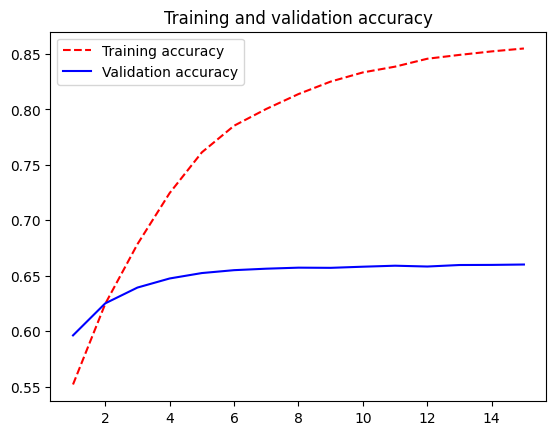

In [23]:
plot_history(history, "accuracy")

In [24]:
seq2seq_rnn = tf.keras.models.load_model(MODELS_DIR / "seq-to-seq-gru.en_spa.keras")
print(f"Val acc: {seq2seq_rnn.evaluate(val_ds, verbose=0)[1]:.3f}")

Val acc: 0.652


#### Translating new sentences with our RNN encoder and decoder

In [25]:
def generate_translation(input_sentence):
    # tokenize the original sentence
    tokenized_input_sentence = english_tokenizer([input_sentence])
    # our translation will start with '[start]'
    decoded_sentence = "[start]"
    # decode up to the max length
    for i in range(SEQUENCE_LENGTH):
        # tokenize: this gives us an array of fixed length, (batch=1, SEQUENCE_LENGTH + 1)
        tokenized_target_sentence = spanish_tokenizer([decoded_sentence])
        # pass both sentences to the model
        inputs = [tokenized_input_sentence, tokenized_target_sentence]
        next_token_predictions = seq2seq_rnn.predict(inputs, verbose=0)
        # predictions has as many steps as `tokenized_target_sentence`: take the max prediction at i
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        # decode from token to string & append
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        # if reaching the end before max length, break
        if sampled_token == "[end]":
            break
    return decoded_sentence

In [26]:
spa_vocab = spanish_tokenizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
test_eng_texts = [pair[0] for pair in test_pairs]

In [27]:
for _ in range(20):
    input_sentence = random.choice(test_eng_texts)
    print("-")
    print(input_sentence)
    print(generate_translation(input_sentence))

-
He telephoned me again and again.
[start] Él me llamó a ayudarme y otra vez [end]
-
A magnet can pick up and hold many nails at a time.
[start] un helicóptero puede [UNK] un paseo y un [UNK] puede dólares por un tiempo [end]
-
You're going in the wrong direction.
[start] vas a la dirección equivocada [end]
-
Tom and Mary are still arguing.
[start] tom y mary están discutiendo [end]
-
What's your favorite self-help book?
[start] cuál es tu grupo preferido de disney [end]
-
I decided to go to college to major in English.
[start] decidí ir a la universidad en inglés [end]
-
In my city, there is no school for learning Esperanto.
[start] en mi colegio no hay muchos meses para aprender francés [end]
-
Don't deceive him.
[start] no lo engañes [end]
-
His whole family is like that.
[start] toda su familia es así [end]
-
He used pigeons in his experiment.
[start] Él gastó su experimento en el experimento [end]
-
Tom should definitely ask for Mary's opinion.
[start] tom debería oír a mary el n

---

## The Transformer architecture

### Intro

<!-- <img style="float:right" src="images/transformer/the-annotated-transformer_14_0.transformer-full.png"> -->
<img style="float:right" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/the-annotated-transformer_14_0.transformer-full.png">


<small style="position:absolute;bottom:0;right:0">[Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)</small>

The **Transformer** architecture was developed for NLP, specifically for translation.

The dual architecture pattern (*sequence to sequence*) reflects this:
- the left-hand side transforms an **input** sentence into abstract representations;
- the right hand side transforms the **output** sentence into abstract representations, integrating abstract representations from the **input sequence** as well;
- the output probabilities ("what is the next token?") are produced on the basis of both branches!

### Note: Einstein Summation

See [this part](https://deeplearningwithpython.io/chapters/chapter15_language-models-and-the-transformer/#the-transformer-architecture) (scroll down a bit).

Rules:
- For any **repeated** letters across inputs (comma separated), **multiply** values along these axes together (dimensions should match).
- For any letters in the input but **not** the output, **sum over these axes**.
- Output axes can be returned in **any order**.

In [28]:
a = np.random.randint(0, 5, size=(2,3))
# transpose: flip the dimensions
a_t = np.einsum("ij->ji", a)
print(f"{a.shape = } -> {a_t.shape = }")

a.shape = (2, 3) -> a_t.shape = (3, 2)


In [29]:
b = np.random.randint(0, 5, size=(3, 2))
# matmul: multiply along i & k, sum over j
a_mm_b = np.einsum("ij,jk->ik", a, b)
print(f"{a.shape = }, {b.shape = } -> {a_mm_b.shape = }")

a.shape = (2, 3), b.shape = (3, 2) -> a_mm_b.shape = (2, 2)


In [30]:
c = np.random.randint(0, 5, size=(3, 2,3))
# matmuls a batch of matrices against a single matrix
# multiply along h (broadcasting!), i, k, sum over j
c_mm_b = np.einsum("hij,jk->hik", c, b)
print(f"{c.shape = }, {b.shape = } -> {c_mm_b.shape = }")

c.shape = (3, 2, 3), b.shape = (3, 2) -> c_mm_b.shape = (3, 2, 2)


In [31]:
d = np.random.randint(0, 5, size=(3,))
# dot-product: multiply & sum over i
d_dot = np.einsum("i,i->", d, d)
print(f"{d.shape = } -> {d_dot.shape = }")

d.shape = (3,) -> d_dot.shape = ()


In [32]:
# element-wise multiplication
# multiply over i, j, k
c_elwise_mul_ = np.einsum("ijk,ijk->ijk", c, c)
print(f"{c.shape = } -> {c_elwise_mul_.shape = }")

c.shape = (3, 2, 3) -> c_elwise_mul_.shape = (3, 2, 3)


In [33]:
# element-wise multiplies and sums everything
# multiply & sum over i, j, k
c_elwise_mul_sum = np.einsum("ijk,ijk->", c, c)
print(f"{c.shape = } -> {c_elwise_mul_sum.shape = }")

c.shape = (3, 2, 3) -> c_elwise_mul_sum.shape = ()


Recommended tutorials and advanced techniques:
- [`np.einsum`](https://numpy.org/devdocs/reference/generated/numpy.einsum.html)
- [`torch.einsum`](https://docs.pytorch.org/docs/stable/generated/torch.einsum.html)
- [`keras.ops.einsum`](https://keras.io/api/ops/numpy/#einsum-function), [`keras.layers.EinsumDense`](https://keras.io/api/layers/core_layers/einsum_dense/)
- Separate [`einops`](https://github.com/arogozhnikov/einops) library with interesting example notebooks!

### Understanding self-attention

#### Generalized self-attention: the query-key-value model

<!-- ![Stanford CS224n soft look-up](images/cs224n/02.soft-lookup.png) -->
<img style="height:750px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/cs224n/02.soft-lookup.png">

[Stanford CS224n, lecture 8](https://web.stanford.edu/class/cs224n/slides/cs224n-2023-lecture08-transformers.pdf#page=8&zoom=auto,-74,536) ([lecture](https://www.youtube.com/watch?v=LWMzyfvuehA))

##### The operations of attention

1. First, we **transform our input sequence** $X$ `(timesteps_x, embedding_dim_x)` by integrating information from a context sequence $Y$ `(timesteps_y, embedding_dim_y)`, each token is a vector embedding) into **Keys**, **Queries**, and **Values**, using three different matrices (here denoted $W$):

$$
Q = XW_Q, \qquad K = YW_K, \qquad V = YW_V
$$

With:
- $t$ denotes time steps, $d$ embedding dimensions, $Tx$ and $t_Y$ are the lengths of the respective sequences, and $d_k$ is the space dimension of the attention operation, `attn_dim`:

| input sequences | projection matrices | queries, keys, values |
| --- | --- | ---|
| $X$: $Tx \times d_x$ | $W_Q$: $d_x \times d_k$   | $Q$: $ Tx \times d_k $ |
| $Y$: $t_Y \times d_y$| $W_K$: $d_y \times d_k$ | $K$: $ t_Y \times d_k$ |
| | $W_V$: $ d_y \times  d_{out}$ | $V$: $  t_Y \times d_{out}$ |


**Note**: Very often (in self-attention) $X = Y$, we aggregate input $X$ with itself. That means that $d_X = d_Y$. Also, often $d_{out} = d_{embed}$: our output sequence has the same number of time steps as our input, and the same embedding dimension.

2. Then, we perform the **attention** proper:

$$
\begin{align*}
\mathrm{Attention}(Q, K, V) &= softmax(\frac{QK^T}{\sqrt{d_k}})V\\
\\
& = softmax(\frac{QK^T}{scaling})V \\
\\
&= \bbox[5px,border:2px solid red]{“softmax(\mathrm{Queries} \cdot \mathrm{Keys)} \cdot \mathrm{Values}”}\\
\\
&= \underbrace{ \underbrace{ softmax( \overbrace{ \mathrm{Queries} \cdot \mathrm{Keys} }^{  \text{how much each source token is compatible with all context tokens} } )  }_{ \text{turn compatibilities into a normalised mask} } \cdot \mathrm{Values}  }_{ \text{turn each token into a weighted average of all context tokens} }\\
\end{align*}
$$

$Q$: queries ($Tx \times d_k$)  
$K$: keys ($t_Y \times d_k$)  
$V$: values ($t_Y \times d_{out}$)  
$\sqrt{d_k}$: scaling factor, $d_k$: dimension of $Q$ (same as $K$ for self-attention), to prevent small gradients.

##### Attention in NumPy

In [78]:
np.random.seed(42)

# sequence length
Tx = 5
# embed dim
Dk = 4

Q = np.random.randint(0, 10, size=(Tx, Dk)).astype("float")

# the timesteps are displayed vertically (each row is like a token vector)
Q

array([[6., 3., 7., 4.],
       [6., 9., 2., 6.],
       [7., 4., 3., 7.],
       [7., 2., 5., 4.],
       [1., 7., 5., 1.]])

In [79]:
# note: when doing self-attention, Ty is the same as Tx
Ty = 3
K = np.random.randint(0, 10, size=(Ty, Dk)).astype("float")

K

array([[4., 0., 9., 5.],
       [8., 0., 9., 2.],
       [6., 3., 8., 2.]])

- We saw the concept of a **gate** being like a smooth 1/0 switch. Here the *softmax* is used in the same way, for a whole array of values (letting more or less information flow through from different tokens as you mix/average their values).
- The dot product is a fairly straightforward **similarity measure** between two vectors.

In [80]:
# attn = Q @ K.T
attn = np.einsum("ij,jk->ik", Q, np.einsum("ij->ji", K))

# attention matrix: each row represents one time step in Q
# and how 'compatible' it is with each timestep in K
print(attn)
print(f"{attn.shape = }")

[[107. 119. 109.]
 [ 72.  78.  91.]
 [ 90.  97.  92.]
 [ 93. 109.  96.]
 [ 54.  55.  69.]]
attn.shape = (5, 3)


In [81]:
attn_softmax = keras.ops.softmax(attn * (Dk ** - 0.5), axis=-1).numpy()

print(attn_softmax)

[[2.45611490e-03 9.90867473e-01 6.67641251e-03]
 [7.47338781e-05 1.50107007e-03 9.98424196e-01]
 [2.71490261e-02 8.99052270e-01 7.37987043e-02]
 [3.34846877e-04 9.98164474e-01 1.50067959e-03]
 [5.52275305e-04 9.10548043e-04 9.98537177e-01]]


In [82]:
# (each row is now normalized to sum to one)
print(attn_softmax.sum(axis=-1))

[1. 1. 1. 1. 1.]


In [83]:
np.random.seed(5)

# the dimension of the output tensor (same as Dk for simplicity)
Dout = Dk

V = np.random.randint(0, 10, size=(Ty, Dout)).astype("float")

# the timesteps are displayed vertically (each row is like a token vector)
V

array([[3., 6., 6., 0.],
       [9., 8., 4., 7.],
       [0., 0., 7., 1.]])

In [84]:
# use the attention matrix to compute the aggregation for all timesteps
# and for all dimensions of V (each dimension is aggregated separately
# out = attn_softmax @ V
out = np.einsum("ij,jk->ik", attn_softmax, V)

# the output has as many timesteps as K (5), and each number is an aggregation
# of the timesteps of V below (so vertically – compute each embed dimension separately)
print(out)

[[8.9251756  7.94167647 4.02494147 6.94274872]
 [0.01373383 0.01245696 6.99542206 1.00893169]
 [8.1729175  7.35531231 4.27569417 6.36716459]
 [8.9844848  7.98732487 4.00517173 6.98865199]
 [0.00985176 0.01059804 6.99671608 1.00491101]]


In [85]:
V

array([[3., 6., 6., 0.],
       [9., 8., 4., 7.],
       [0., 0., 7., 1.]])

In [86]:
# Our attention matrix aggregates all the timesteps of V using that 'mask'
# (thanks to the softmax, the 'total information' remains constant <-> sum to one,
# a weighted average) -> creating new values for each timestep
# in this case, we'll take 99.9% of the value of the second timestep
[f"{x:.12f}" for x in attn_softmax[0]]

['0.002456114904', '0.990867472582', '0.006676412513']

In [87]:
print("Each first row element of `out` is composed almost exclusively of the second timestep of V:")
print("out[0]:", out[0])
print("V, second timestep vector:", V[1])
print()
print(f"{out.shape = }")

Each first row element of `out` is composed almost exclusively of the second timestep of V:
out[0]: [8.9251756  7.94167647 4.02494147 6.94274872]
V, second timestep vector: [9. 8. 4. 7.]

out.shape = (5, 4)


- Attention uses the dot product to compute the compatibility between vectors of $Q$ and $K$.
- It then normalizes those scores (softmax) to extract a weighted average of each dimension of $V$.
- That is, each timestep in the new vector will be a vector the dimensions of which are

The shape of $V$ has as many timesteps as $Q$, and usually the same embed dimension (but that could be changed).

#### Causal Masking: Preventing look-aheads

Notice the **optional masking operation**: on the right-hand side of the Transformer (generation), we use a mask that effectively prevents any look-up into the future.

<!-- <img style="float:right;height:300px" src="images/transformer/the-annotated-transformer_33_0.attention.png"> -->
<img  style="float:right;height:300px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/the-annotated-transformer_33_0.attention.png">

<small style="position:absolute;bottom:0;right:0">[Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)</small>

<!-- ![Stanford CS224n masked attention](images/cs224n/08.masked-attention.png) -->
<img style="height: 400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/cs224n/08.masked-attention.png">

[Stanford CS224n, lecture 8, p.19](https://web.stanford.edu/class/archive/cs/cs224n/cs224n.1234/slides/cs224n-2023-lecture08-transformers.pdf) ([lecture](https://www.youtube.com/watch?v=LWMzyfvuehA))

##### Causal Masking in NumPy

In [88]:
# this would be how Q attends to itself
self_attn = np.einsum("ij,jk->ik", Q, np.einsum("ij->ji", Q))
self_attn

array([[110., 101., 103.,  99.,  66.],
       [101., 157., 126.,  94.,  85.],
       [103., 126., 123., 100.,  57.],
       [ 99.,  94., 100.,  94.,  50.],
       [ 66.,  85.,  57.,  50.,  76.]])

In [89]:
i = keras.ops.arange(Tx)[:, None]
j = keras.ops.arange(Tx)[None, :]
# same broadcasting trick as in the cbow model
causal_mask = keras.ops.cast(i >= j, self_attn.dtype).numpy()
causal_mask

array([[1., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0.],
       [1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1.]])

In [90]:
causal_mask_inf = ((1.0 - causal_mask) * -1e9)
causal_mask_inf

array([[-0.e+00, -1.e+09, -1.e+09, -1.e+09, -1.e+09],
       [-0.e+00, -0.e+00, -1.e+09, -1.e+09, -1.e+09],
       [-0.e+00, -0.e+00, -0.e+00, -1.e+09, -1.e+09],
       [-0.e+00, -0.e+00, -0.e+00, -0.e+00, -1.e+09],
       [-0.e+00, -0.e+00, -0.e+00, -0.e+00, -0.e+00]])

In [91]:
attn_causal_inf = self_attn + causal_mask_inf
print(attn_causal_inf)

[[ 1.10000000e+02 -9.99999899e+08 -9.99999897e+08 -9.99999901e+08 -9.99999934e+08]
 [ 1.01000000e+02  1.57000000e+02 -9.99999874e+08 -9.99999906e+08 -9.99999915e+08]
 [ 1.03000000e+02  1.26000000e+02  1.23000000e+02 -9.99999900e+08 -9.99999943e+08]
 [ 9.90000000e+01  9.40000000e+01  1.00000000e+02  9.40000000e+01 -9.99999950e+08]
 [ 6.60000000e+01  8.50000000e+01  5.70000000e+01  5.00000000e+01  7.60000000e+01]]


In [92]:
attn_causal_softmax = keras.ops.softmax(attn_causal_inf * Dk ** - 0.5, axis=-1).numpy()
attn_causal_softmax

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.91440011e-13, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.28203737e-06, 8.17567705e-01, 1.82424013e-01, 0.00000000e+00, 0.00000000e+00],
       [3.55506098e-01, 2.91817176e-02, 5.86130466e-01, 2.91817176e-02, 0.00000000e+00],
       [7.40238945e-05, 9.88939009e-01, 8.22331187e-07, 2.48322502e-08, 1.09861200e-02]])

In [93]:
out_causal = np.einsum("ij,jk->ik", attn_causal_softmax, Q)

# now, if you look at Q below, the first step is preserved as is,
# since it only attends to itself, whilst the last row aggregates
# all the timesteps of Q according to the softmaxed values above
out_causal

array([[6.        , 3.        , 7.        , 4.        ],
       [6.        , 9.        , 2.        , 6.        ],
       [6.18242401, 8.08783024, 2.18246542, 6.18240745],
       [6.61531218, 3.73203905, 4.45120611, 5.81675483],
       [5.94507025, 8.97757933, 2.03332938, 5.94492212]])

In [94]:
Q

array([[6., 3., 7., 4.],
       [6., 9., 2., 6.],
       [7., 4., 3., 7.],
       [7., 2., 5., 4.],
       [1., 7., 5., 1.]])

---

#### Multi-head attention

The author found it beneficial to **subdivide the embedding space** into multiple $Queries$, $Keys$ and $Values$, each called **attention heads** looking for different *types* of information (each looks at the **whole sequence** differently)! Perk: the overall matrix multiplication operations and shapes remain the same.

*Similar to the idea of several kernels scanning the same image in search of different features!*

<!-- <img style="float:right;height:400px" src="images/transformer/the-annotated-transformer_38_0.multi-head.png"> -->
<img style="float:right;height:400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/the-annotated-transformer_38_0.multi-head.png">


<small style="position:absolute;bottom:0;right:0">[Vaswani et al, "Attention Is All You Need"](https://arxiv.org/abs/1706.03762)</small>

<!-- ![Stanford CS224n multi-head attention](images/cs224n/06.multi-head.2.png) -->
<img style="height:400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/cs224n/06.multi-head.2.png">

[Stanford CS224n, lecture 8, p.26](https://web.stanford.edu/class/archive/cs/cs224n/cs224n.1234/slides/cs224n-2023-lecture08-transformers.pdf) ([lecture](https://www.youtube.com/watch?v=LWMzyfvuehA))

##### Multi-Head Attention in NumPy

In [51]:
Q

array([[6., 3., 7., 4.],
       [6., 9., 2., 6.],
       [7., 4., 3., 7.],
       [7., 2., 5., 4.],
       [1., 7., 5., 1.]])

In [52]:
# two heads
H = 2
# inner dim Dk must be divisible by H
Dh = Dk // H

# now we have (timesteps, heads, embed_dim)
Q_split_heads = Q.reshape(Tx, H, Dh)
print(f"{Q_split_heads.shape = }")

# we bring heads to the front
Q_heads = np.einsum("ihk->hik", Q_split_heads)
print(f"{Q_heads.shape = }")

# the vectors of Q have been split alongside the embed dimension
Q_heads

Q_split_heads.shape = (5, 2, 2)
Q_heads.shape = (2, 5, 2)


array([[[6., 3.],
        [6., 9.],
        [7., 4.],
        [7., 2.],
        [1., 7.]],

       [[7., 4.],
        [2., 6.],
        [3., 7.],
        [5., 4.],
        [5., 1.]]])

In [53]:
K_heads = np.einsum("ihk->hik", K.reshape(Ty, H, Dh))
print(f"{K_heads.shape = }")

K_heads.shape = (2, 3, 2)


In [54]:
# we perform the same attention operation, one for each head
attn_heads = np.einsum("hik,hkj->hij", Q_heads, np.einsum("hjk->hkj", K_heads))
print(f"{attn_heads.shape = }")

# we now have two attention matrices creating two ways of connecting
# the vectors at timesteps of K (5) and Q (4)
attn_heads

attn_heads.shape = (2, 5, 3)


array([[[24., 48., 45.],
        [24., 48., 63.],
        [28., 56., 54.],
        [28., 56., 48.],
        [ 4.,  8., 27.]],

       [[83., 71., 64.],
        [48., 30., 28.],
        [62., 41., 38.],
        [65., 53., 48.],
        [50., 47., 42.]]])

In [55]:
# (the rest of the operations – masking, etc. – are the same)
attn_heads_softmax = keras.ops.softmax(attn_heads * Dk ** -0.5, axis=-1).numpy()
print(f"{attn_heads_softmax.shape = }")

# reshape V by splitting the heads and bringing heads forward
# (Ty, H, Dh) -> (H, Ty, Dh)
V = np.einsum("jhk->hjk", V.reshape(Ty, H, Dh))
print(f"{V.shape = }")

# (H, Tx, Ty) (H, Ty, Dh) -> (H, Tx, Dh)
out_heads = np.einsum("hij,hjk->hik", attn_heads_softmax, V)
print(f"{out_heads.shape = }")

# bring the heads back from the front, merge the embed dim
# (this last bit can also be done with a matmul/linear projection)
# (H, Tx, Dh) -> (Tx, H, Dh) ->  (Tx, Dk)
out_heads_merged = np.einsum("hik->ihk", out_heads).reshape(Tx, Dk)

# remember, our Tx (Query timesteps)
print(f"{out_heads_merged.shape = }")

attn_heads_softmax.shape = (2, 5, 3)
V.shape = (2, 3, 2)
out_heads.shape = (2, 5, 2)
out_heads_merged.shape = (5, 4)


#### Visualising what Attention learns

Attention allows a network to make decisions about the importance of various parts of the input, and learn **complex internal patterns**.

In this example, "it" could refer to "animal" or to "street", and resolving this depends on **meaning** (and syntax). After attention, the embedding for "it" will have changed according to its context!

<!-- <div style="display:flex;justify-content:center">
    <img src="images/transformer/attention.png">
    <img src="images/transformer/attention.2.png">
</div> -->

<div style="display:flex">
    <img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/attention.png">
    <img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/attention.2.png">
</div>

<small>["Transformer: A Novel Neural Network Architecture for Language Understanding", Google Reseearch Blog](https://ai.googleblog.com/2017/08/transformer-novel-neural-network.html)</small>

See also the NumPy & BERT visualisations in the reference notebook.

**Yet again, the best series of introduction videos on this is by [Grant Sanderson/3Blue1Brown](https://www.youtube.com/watch?v=wjZofJX0v4M&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=6), do check them out!**

#### Self-attention and Cross attention

In the standard case, we are calculating the similarity of parts of the data **with itself**.

We are creating a **new representation** of the word 'station' taking the context into account.

For example, our new representation would know this station is a *train* (not space or radio) station...

It is possible to have a query coming from one source (**target**) and the key/values from another (**source**)!

<!-- <img style="float:right;height:400px" src="images/transformer/beyer.cross-attention.png"> -->
<img style="float:right;height:400px"  src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/beyer.cross-attention.png">

<small style="position:absolute;bottom:0;right:0">[Lucas Beyer, "Transformers"](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit#slide=id.g13dd67c5ab8_0_79)</small>

#### A few more bells & whistles (as always, with current architectures)

- Technically there's almost no nonlinearity in attention → add **dense nets between attention blocks** (MLP: "multilayer perceptron")!
- Using **Layer Normalization** to stabilise the data & gradient flow;
- Using **Residual Connections** to stabilise the data & gradient flow;
- Using fancy **learning rate schedules** during training.

---

## Sequence-to-sequence learning with Transformer

#### Transformers: Three variants/applications

<!-- <img style="float:right;height:550px" src="images/transformer/beyer.gpt-bert-t5.png"> -->
<img style="float:right;height:550px"  src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/beyer.gpt-bert-t5.png">

<small style="position:absolute;bottom:0;right:0">[Lucas Beyer, "Transformers"](https://docs.google.com/presentation/d/1ZXFIhYczos679r70Yu8vV9uO6B1J0ztzeDxbnBxD1S0/edit)</small>

### A MultiHeadAttention Layer

After studying this implementation, it's possible to use [`keras.layers.MultiHeadAttention`](https://keras.io/api/layers/attention_layers/multi_head_attention/).

Also, the [`keras.layers.EinsumDense` docs](https://keras.io/api/layers/core_layers/einsum_dense/)

In [56]:
# Keras source: https://github.com/keras-team/keras/blob/e29d0efbefe21b80c041849bd73cc3e54c872de3/keras/src/layers/attention/multi_head_attention.py#L20
# see: https://chatgpt.com/share/69a8c2fe-50a4-8005-b57d-4349e69b47e5
#      https://claude.ai/share/e0f0d36b-c713-45e3-a060-ec4ee1b52d90
#      https://claude.ai/share/81847461-37b3-4536-b140-9785bfd7de2c

class MultiHeadAttention(keras.Layer):
    def __init__(self, num_heads, key_dim, dropout=0.0, seed=None, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads             # H
        self.key_dim = key_dim                 # K
        self.hidden_dim = num_heads * key_dim  # D
        self.dropout = dropout
        self.seed = seed

    def build(self, input_shape):
        # B: batch, T: timesteps, D: total hidden dim (H*K), H: heads, K: key dim
        # (B, T, D) → (B, T, H, K)
        self.q_proj = keras.layers.EinsumDense(
            "btd,dhk->bthk", output_shape=(None, self.num_heads, self.key_dim), bias_axes="hk"
        )
        self.k_proj = keras.layers.EinsumDense(
            "btd,dhk->bthk", output_shape=(None, self.num_heads, self.key_dim), bias_axes="hk"
        )
        self.v_proj = keras.layers.EinsumDense(
            "btd,dhk->bthk", output_shape=(None, self.num_heads, self.key_dim), bias_axes="hk"
        )

        # (B, T, H, K) → (B, T, D)
        self.out_proj = keras.layers.EinsumDense(
            "bthk,hkd->btd", output_shape=(None, self.hidden_dim), bias_axes="d"
        )

        self.dropout_layer = keras.layers.Dropout(rate=self.dropout, seed=self.seed)

        super().build(input_shape)

    def call(self, query, key=None, value=None, attention_mask=None, use_causal_mask=False, training=None):
        if key is None:
            key = query
        if value is None:
            value = key

        # project to heads directly
        q = self.q_proj(query)  # (B, Tq, H, K)
        k = self.k_proj(key)    # (B, Tk, H, K)
        v = self.v_proj(value)  # (B, Tk, H, K)

        # move heads forward for attention
        q = keras.ops.einsum("bthk->bhtk", q)  # (B, H, Tq, K)
        k = keras.ops.einsum("bthk->bhtk", k)  # (B, H, Tk, K)
        v = keras.ops.einsum("bthk->bhtk", v)  # (B, H, Tk, K)

        # scaled dot-product attention
        scale = self.key_dim ** -0.5
        # q x k.T, (B, H, Tq, K) x (B, H, K, Tk) -> (B, H, Tq, Tk)
        scores = keras.ops.matmul(q, keras.ops.einsum("bhtk->bhkt", k)) * scale

        if attention_mask is not None:
            # Keras convention: (B, T, S) — 1 means attend, 0 means ignore
            # expand to (B, 1, Tq, Tk) to broadcast over heads
            mask = keras.ops.expand_dims(attention_mask, axis=1)  # (B, 1, Tq, Tk)
            scores += (1.0 - keras.ops.cast(mask, scores.dtype)) * -1e9

        if use_causal_mask:
            Tq = keras.ops.shape(scores)[2]
            Tk = keras.ops.shape(scores)[3]
            i = keras.ops.arange(Tq)[:, None]
            j = keras.ops.arange(Tk)[None, :]
            # same broadcasting trick as in the cbow model
            causal_mask = keras.ops.cast(i >= j, scores.dtype)  # (Tq, Tk)
            # add batch & head dimension for broadcasting later
            causal_mask = causal_mask[None, None, :, :]         # (1, 1, Tq, Tk)
            # replace masked slots (zeros) with -∞, the rest is zero: no influence
            scores += (1.0 - causal_mask) * -1e9

        weights = keras.ops.softmax(scores, axis=-1)
        weights = self.dropout_layer(weights, training=training)
        # attention! retrieving from values using softmaxed weights
        attention = keras.ops.matmul(weights, v)  # (B,H,Tq,K)

        # swap heads back to (B, Tq, H, K)
        attention = keras.ops.einsum("bhtk->bthk", attention)

        # final projection to (B, Tq, D)
        return self.out_proj(attention)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "key_dim": self.key_dim,
            "dropout": self.dropout,
            "seed": self.seed,
        })
        return config

##### Test `attention_mask` (padding)

In [57]:
# Keras convention: (B, T, S) — 1 means attend, 0 means ignore.
attention_mask = np.ones(shape=(1, 10, 3))
attention_mask[:,:2,...] = 0
print(attention_mask.shape)

# Expand to (B, 1, Tq, Tk) to broadcast over heads.
mask = keras.ops.expand_dims(attention_mask, axis=1)  # (B, 1, Tq, Tk)

print()
print("Here, the time dimension is vertical – each timestep is a vector (row).")
print(mask.shape)
print(mask)

print()
print("The numbers where there was a zero ('padding/discard'), end up being -∞ -> zero after softmax:")
mask = (1.0 - keras.ops.cast(mask, "float32")) * -1e9
print(mask)

(1, 10, 3)

Here, the time dimension is vertical – each timestep is a vector (row).
(1, 1, 10, 3)
tf.Tensor(
[[[[0. 0. 0.]
   [0. 0. 0.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]
   [1. 1. 1.]]]], shape=(1, 1, 10, 3), dtype=float64)

The numbers where there was a zero ('padding/discard'), end up being -∞ -> zero after softmax:
tf.Tensor(
[[[[-1.e+09 -1.e+09 -1.e+09]
   [-1.e+09 -1.e+09 -1.e+09]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]
   [-0.e+00 -0.e+00 -0.e+00]]]], shape=(1, 1, 10, 3), dtype=float32)


##### Test `causal_attention_mask` (prevent look-aheads)

In [58]:
Tq = 5
Tk = 5
i = keras.ops.arange(Tq)[:, None]
j = keras.ops.arange(Tk)[None, :]
causal_mask = keras.ops.cast(i >= j, "float32") # (Tq, Tk)
causal_mask = causal_mask[None, None, :, :]     # (1, 1, Tq, Tk)
causal_mak = (1.0 - causal_mask) * -1e9

print("Using broadcasting between a column and a row vector")
print()
print(i)
print()
print(j)
print()
print(" -> matrix:")
print()
print(causal_mask)

print()
print("Causal mask, to be read horizontally (1st row = 1st timestep: only 1st column is allowed, i.e.")
print("attending to itself only; 2nd row, 2nd timestep, allowed to attend to itself and the previous one):")

print()
print("The numbers where there was a zero ('not allowed'), end up being -∞ -> zero after softmax:")
print()
print(causal_mak)

Using broadcasting between a column and a row vector

tf.Tensor(
[[0]
 [1]
 [2]
 [3]
 [4]], shape=(5, 1), dtype=int32)

tf.Tensor([[0 1 2 3 4]], shape=(1, 5), dtype=int32)

 -> matrix:

tf.Tensor(
[[[[1. 0. 0. 0. 0.]
   [1. 1. 0. 0. 0.]
   [1. 1. 1. 0. 0.]
   [1. 1. 1. 1. 0.]
   [1. 1. 1. 1. 1.]]]], shape=(1, 1, 5, 5), dtype=float32)

Causal mask, to be read horizontally (1st row = 1st timestep: only 1st column is allowed, i.e.
attending to itself only; 2nd row, 2nd timestep, allowed to attend to itself and the previous one):

The numbers where there was a zero ('not allowed'), end up being -∞ -> zero after softmax:

tf.Tensor(
[[[[-0.e+00 -1.e+09 -1.e+09 -1.e+09 -1.e+09]
   [-0.e+00 -0.e+00 -1.e+09 -1.e+09 -1.e+09]
   [-0.e+00 -0.e+00 -0.e+00 -1.e+09 -1.e+09]
   [-0.e+00 -0.e+00 -0.e+00 -0.e+00 -1.e+09]
   [-0.e+00 -0.e+00 -0.e+00 -0.e+00 -0.e+00]]]], shape=(1, 1, 5, 5), dtype=float32)


### The Transformer encoder

After studying this implementation, it's possible to use [`keras_hub.layers.TransformerEncoder`](https://keras.io/keras_hub/api/modeling_layers/transformer_encoder/)

In [59]:
# see: https://chatgpt.com/share/69a036bb-40e8-8005-acda-e8adeb307e87

if USE_KERAS_IMPL:
    MultiHeadAttention = keras.layers.MultiHeadAttention

class TransformerEncoder(keras.Layer):
    def __init__(self, intermediate_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.intermediate_dim = intermediate_dim
        self.num_heads = num_heads

    # new in Keras 3, see: https://keras.io/guides/making_new_layers_and_models_via_subclassing/#best-practice-deferring-weight-creation-until-the-shape-of-the-inputs-is-known
    def build(self, input_shape):
        hidden_dim = input_shape[-1] # infer from input
        key_dim = hidden_dim // self.num_heads
        self.self_attention = MultiHeadAttention(self.num_heads, key_dim)
        self.self_attention_layernorm = keras.layers.LayerNormalization()
        self.feed_forward_1 = keras.layers.Dense(self.intermediate_dim, activation="relu")
        self.feed_forward_2 = keras.layers.Dense(hidden_dim)
        self.feed_forward_layernorm = keras.layers.LayerNormalization()
        super().build(input_shape)

    def call(self, inputs, padding_mask=None):
        residual = x = inputs

        # 1. source sentence (the one we are only reading)
        # (non-causal) cross-attention, residual, layernorm, residual (mask for padding)
        mask = padding_mask[:, None, :] if padding_mask is not None else None
        x = self.self_attention(query=x, key=x, value=x, attention_mask=mask)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x

        # 2. MLP on top (reinjecting non-linearity into the system), residual, layernorm
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

    # retrieve config as a dict (necessary for custom Keras layers)
    def get_config(self):
        config = super().get_config()
        config.update({
            "intermediate_dim": self.intermediate_dim,
            "num_heads": self.num_heads,
            "name": self.name,
        })
        return config

### The Transformer decoder

After studying this implementation, it's possible to use [`keras_hub.layers.TransformerDecoder`](https://keras.io/keras_hub/api/modeling_layers/transformer_decoder/)

In [60]:
if USE_KERAS_IMPL:
    MultiHeadAttention = keras.layers.MultiHeadAttention

class TransformerDecoder(keras.Layer):
    def __init__(self, intermediate_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.intermediate_dim = intermediate_dim
        self.num_heads = num_heads

    # new in Keras 3, see: https://keras.io/guides/making_new_layers_and_models_via_subclassing/#best-practice-deferring-weight-creation-until-the-shape-of-the-inputs-is-known
    def build(self, input_shape):
        hidden_dim = input_shape[-1] # infer from input
        key_dim = hidden_dim // self.num_heads
        self.self_attention = MultiHeadAttention(self.num_heads, key_dim)
        self.self_attention_layernorm = keras.layers.LayerNormalization()
        self.cross_attention = MultiHeadAttention(self.num_heads, key_dim)
        self.cross_attention_layernorm = keras.layers.LayerNormalization()
        self.feed_forward_1 = keras.layers.Dense(self.intermediate_dim, activation="relu")
        self.feed_forward_2 = keras.layers.Dense(hidden_dim)
        self.feed_forward_layernorm = keras.layers.LayerNormalization()
        super().build(input_shape)

    def call(self, decoder_sequence, encoder_sequence, encoder_padding_mask=None):
        residual = x = decoder_sequence

        # 1. target sentence (the one we are reading AND writing)
        # *causal!* self-attention, residual, layernorm, residual (q, k, v are all x)
        x = self.self_attention(query=x, key=x, value=x, use_causal_mask=True)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x

        # 2. source sentence (the one we are only reading)
        # (non-causal) cross-attention, residual, layernorm, residual (mask for padding)
        mask = encoder_padding_mask[:, None, :] if encoder_padding_mask is not None else None
        x = self.cross_attention(
            # note: q is the target sentence, but k, v are the source
            query=x, key=encoder_sequence, value=encoder_sequence, attention_mask=mask
        )
        x = x + residual
        x = self.cross_attention_layernorm(x)
        residual = x

        # 3. MLP on top (reinjecting non-linearity into the system), residual, layernorm
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

    # retrieve config as a dict (necessary for custom Keras layers)
    def get_config(self):
        config = super().get_config()
        config.update({
            "intermediate_dim": self.intermediate_dim,
            "num_heads": self.num_heads,
            "name": self.name,
        })
        return config

### Sequence-to-sequence learning with a Transformer

Our first version only uses the base embedding layer.

In [61]:
EMBED_DIM = 256
INTERMEDIATE_DIM = 2048
NUM_HEAD = 8

if USE_KERAS_IMPL:
    TransformerEncoder = keras_hub.layers.TransformerEncoder
    TransformerDecoder = keras_hub.layers.TransformerDecoder

source = keras.Input(shape=(None,), dtype="int32", name="english")
x = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)(source)
encoder_output = TransformerEncoder(INTERMEDIATE_DIM, NUM_HEAD)(
    inputs=x,
    padding_mask=source != 0,
)

target = keras.Input(shape=(None,), dtype="int32", name="spanish")
x = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)(target)
x = TransformerDecoder(INTERMEDIATE_DIM, NUM_HEAD)(
    decoder_sequence=x,
    encoder_sequence=encoder_output,
    encoder_padding_mask=source != 0,
)
x = keras.layers.Dropout(0.5)(x)
target_predictions = keras.layers.Dense(VOCAB_SIZE, activation="softmax")(x)
transformer = keras.Model([source, target], target_predictions)

In [62]:
transformer.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spanish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 256) │  3,840,000 │ english[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, None, 256) │  3,840,000 │ spanish[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, None, 256) │  1,315,072 │ embedding_2[0][0… │
│ (TransformerEncode… │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decoder │ (None, None, 256) │  1,578,752 │ embedding_3[0][0… │
│ (TransformerDecode… │                   │            │ not_equal_5[0][0… │
│                     │                   │            │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, None, 256) │          0 │ transformer_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, None,      │  3,855,000 │ dropout_4[0][0]   │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,428,824 (55.04 MB)

 Trainable params: 14,428,824 (55.04 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

EPOCHS=15

history = transformer.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "transformer-no-positional.en_spa.keras",
            save_best_only=True
        ),
        PrintStatsCallback(epochs=EPOCHS),
    ],
    verbose=0,
)

epoch: 15/15 |     batch: 1302/1302 |     accuracy: 0.8272 –     loss: 0.2428
             | val batch:  279/ 279 | val_accuracy: 0.6351 – val_loss: 0.8254



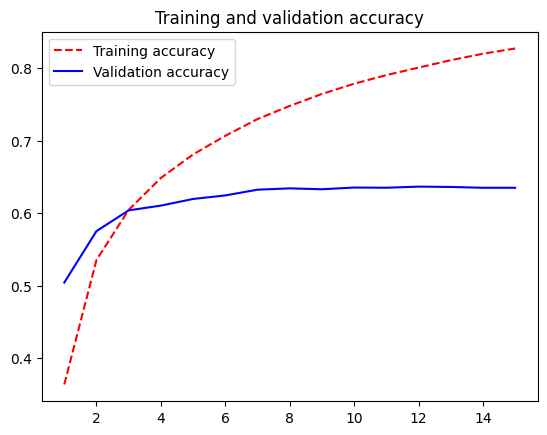

In [64]:
plot_history(history, "accuracy")

In [65]:
transformer = keras.models.load_model(
    MODELS_DIR / "transformer-no-positional.en_spa.keras",
    # when reloading, you need to rerun the class definition above
    # (no need to load custom objects if you trained using keras/keras_hub layers)
    custom_objects={
        "TransformerEncoder": TransformerEncoder,
        "TransformerDecoder": TransformerDecoder,
    }
)
print(f"Val acc: {transformer.evaluate(val_ds, verbose=0)[1]:.3f}")

Val acc: 0.620


#### TokenAndPositionEmbedding layer

**Attention in itself ignores word order!**

But we can reinject that information in the form of a **second embedding layer** that is added to the first one, and whose job is to encode positional information. This time we just embed **positions** (1,2,...).

After studying this implementation, it's possible to use [`keras_hub.layers.TokenAndPositionEmbedding`](https://keras.io/keras_hub/api/modeling_layers/token_and_position_embedding/) (see also the [other embedding layers here](https://keras.io/keras_hub/api/modeling_layers/)).

In [66]:
class TokenAndPositionEmbedding(keras.Layer):
    def __init__(self, vocabulary_size, sequence_length, embedding_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.vocabulary_size = vocabulary_size
        self.embedding_dim = embedding_dim

    # new in Keras 3, see: https://keras.io/guides/making_new_layers_and_models_via_subclassing/#best-practice-deferring-weight-creation-until-the-shape-of-the-inputs-is-known
    def build(self, input_shape):
        # token embeddings: semantic information
        self.token_embeddings = keras.layers.Embedding(self.vocabulary_size, self.embedding_dim)
        # position embeddings: syntactic/spatial information
        self.position_embeddings = keras.layers.Embedding(self.sequence_length, self.embedding_dim)
        super().build(input_shape)

    def call(self, inputs):
        # 1. create token embeddings
        embedded_tokens = self.token_embeddings(inputs)
        # 2. create pos embeddings (as many as our input length)
        positions = keras.ops.cumsum(keras.ops.ones_like(inputs), axis=-1) - 1
        embedded_positions = self.position_embeddings(positions)
        # 3. Both embeddings are simply added together!
        return embedded_tokens + embedded_positions

    # retrieve config as a dict (required for Keras layers)
    def get_config(self):
        config = super().get_config()
        config.update({
            "vocabulary_size": self.vocabulary_size,
            "sequence_length": self.sequence_length,
            "embedding_dim": self.embedding_dim,
        })
        return config

#### End-to-end Transformer

In [67]:
EMBED_DIM = 256
INTERMEDIATE_DIM = 2048
NUM_HEAD = 8

if USE_KERAS_IMPL:
    TokenAndPositionEmbedding = keras_hub.layers.TokenAndPositionEmbedding
    TransformerEncoder = keras_hub.layers.TransformerEncoder
    TransformerDecoder = keras_hub.layers.TransformerDecoder

encoder_inputs = keras.Input(shape=(None,), dtype="int32", name="english")
x = TokenAndPositionEmbedding(VOCAB_SIZE, SEQUENCE_LENGTH, EMBED_DIM)(encoder_inputs)
encoder_outputs = TransformerEncoder(INTERMEDIATE_DIM, NUM_HEAD)(
    inputs=x,
    padding_mask=encoder_inputs != 0,
)

decoder_inputs = keras.Input(shape=(None,), dtype="int32", name="spanish")
x = TokenAndPositionEmbedding(VOCAB_SIZE, SEQUENCE_LENGTH, EMBED_DIM)(decoder_inputs)
x = TransformerDecoder(INTERMEDIATE_DIM, NUM_HEAD)(
    decoder_sequence=x,
    encoder_sequence=encoder_outputs,
    encoder_padding_mask=encoder_inputs != 0,
)
x = keras.layers.Dropout(0.5)(x)
decoder_outputs = keras.layers.Dense(VOCAB_SIZE, activation="softmax")(x)
transformer = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [68]:
transformer.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spanish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, None, 256) │  3,845,120 │ english[0][0]     │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, None, 256) │  3,845,120 │ spanish[0][0]     │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, None, 256) │  1,315,072 │ token_and_positi… │
│ (TransformerEncode… │                   │            │ not_equal_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 256) │  1,578,752 │ token_and_positi… │
│ (TransformerDecode… │                   │            │ not_equal_7[0][0… │
│                     │                   │            │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, None, 256) │          0 │ transformer_deco… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, None,      │  3,855,000 │ dropout_11[0][0]  │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,439,064 (55.08 MB)

 Trainable params: 14,439,064 (55.08 MB)

 Non-trainable params: 0 (0.00 B)

#### Training the sequence-to-sequence Transformer

In [69]:
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"]
)

EPOCHS=30

history = transformer.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / "transformer-positional.en_spa.keras",
            save_best_only=True,
        ),
        PrintStatsCallback(epochs=EPOCHS),
    ],
    verbose=0,
)

epoch: 30/30 |     batch: 1302/1302 |     accuracy: 0.9016 –     loss: 0.1268
             | val batch:  279/ 279 | val_accuracy: 0.6867 – val_loss: 0.8272



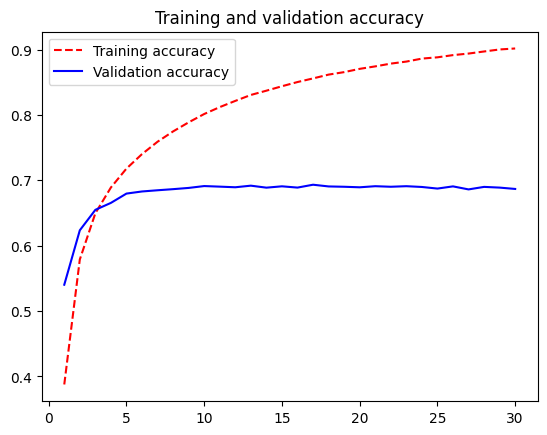

In [70]:
plot_history(history, "accuracy")

In [71]:
transformer = keras.models.load_model(
    MODELS_DIR / "transformer-positional.en_spa.keras",
    # when reloading, you need to rerun the class definition above
    # (no need to load custom objects if you trained using keras/keras_hub layers)
    custom_objects={
        "TransformerEncoder": TransformerEncoder,
        "TransformerDecoder": TransformerDecoder,
        "TokenAndPositionEmbedding": TokenAndPositionEmbedding,
    }
)
print(f"Val acc: {transformer.evaluate(val_ds, verbose=0)[1]:.3f}")

Val acc: 0.683


#### Translating new sentences with our Transformer model

In [72]:
def generate_translation(input_sentence):
    # tokenize the original sentence
    tokenized_input_sentence = english_tokenizer([input_sentence])
    # our translation will start with '[start]'
    decoded_sentence = "[start]"
    # decode up to the max length
    for i in range(SEQUENCE_LENGTH):
        # tokenize: this gives us an array of fixed length, (batch=1, SEQUENCE_LENGTH + 1), discard last step
        tokenized_target_sentence = spanish_tokenizer([decoded_sentence])[:, :-1]
        # pass both sentences to the model
        inputs = [tokenized_input_sentence, tokenized_target_sentence]
        predictions = transformer(inputs)
        # predictions has as many steps as `tokenized_target_sentence`: take the max prediction at i
        sampled_token_index = np.argmax(predictions[0, i, :])
        # decode from token to string & append
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        # if reaching the end before max length, break
        if sampled_token == "[end]":
            break
    return decoded_sentence

In [73]:
spa_vocab = spanish_tokenizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
SEQUENCE_LENGTH = 20
test_eng_texts = [pair[0] for pair in test_pairs]

In [74]:
for _ in range(20):
    input_sentence = random.choice(test_eng_texts)
    print("-")
    print(input_sentence)
    print(generate_translation(input_sentence))

-
He does nothing but watch TV all day long.
[start] Él no hace nada más que ver todo el día [end]
-
We are not too young to tell what love is like.
[start] no somos demasiado jóvenes para decirle lo que es el amor [end]
-
Do I have to do this now?
[start] tengo que hacer esto ahora [end]
-
I don't expect you to be my friend.
[start] no espero que seas mi amigo [end]
-
Keep it secret, please.
[start] por favor [UNK] el secreto [end]
-
It was the calm before the storm.
[start] fue la calma antes de la tormenta [end]
-
Seen from the moon, the earth looks like a ball.
[start] vista de la luna parece que se ve como una pelota [end]
-
I am from France.
[start] soy de francia [end]
-
He described exactly what happened.
[start] Él describió exactamente lo que pasó [end]
-
She gave him a slap in the face.
[start] ella le dio un shock [UNK] en la cara [end]
-
Tom was glad he didn't have to live in Boston for more than a year.
[start] tom estaba contento de que no sabía vivir en boston un año [e

---

### Save models to Google Drive

In [76]:
EXPORT=False

if EXPORT:
    # zip models
    !zip seq-to-seq.models.zip {MODELS_DIR}/*
    # connect to drive
    from google.colab import drive
    drive.mount('/content/drive')
    # copy zip to drive (adjust folder as needed)
    !cp seq-to-seq.models.zip drive/MyDrive/gold/IS53024B-Artificial-Intelligence/models

## Classification with a pretrained Transformer

Learn about it [in the book](https://deeplearningwithpython.io/chapters/chapter15_language-models-and-the-transformer/#classification-with-a-pretrained-transformer).

You can also explore training on the same dataset (IDMB, yet again) but building a Transformer Encoder from scratch in [`08.more/2nd-ed.chapter11_part03_transformer.ipynb`](https://github.com/jchwenger/DLWP/tree/main/lectures/08.more/2nd-ed.chapter11_part03_transformer.ipynb).

## Note: Attention is cheap – if your input sequence is short(ish)

The bulk of the computation happens in the `sequence_length` * `sequence_length` matrices!

<!-- <img src="images/transformer/vaswani-huang.attention-is-cheap.png"> -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/08/images/transformer/vaswani-huang.attention-is-cheap.png">

<small>[Ashish Vaswani and Anna Huang, "Self-Attention For Generative Models", CS224n Stanford](https://web.stanford.edu/class/cs224n/slides/cs224n-2019-lecture14-transformers.pdf)</small>

## Summary

### Experiments

- Encapsulate the transformer model into a class, so that it's easier to create different models with various hyperparameters (number of layers, heads, inner dim, etc.)
- Try and change the tokenization to use e.g. BPE (you can use off-the-shelf classes found on [`KerasHub`](https://keras.io/keras_hub/api/tokenizers/)).

### Attention

- **Neural attention** is a way to create context-aware word representations, the basis for the **Transformer**.
  - The operations are $\bbox[5px,border:2px solid red]{“softmax(\mathrm{Queries} \cdot \mathrm{Keys)} \cdot \mathrm{Values}”}$.
  - **Multi-head** attention allows us to split the attention process (similar to different filters in a CNN), looking up different types of information in the input.
  - To enforce causality / prevent lookaheads into the future, we use **masking** to zero out values.
  - Attention **ignores order**: reinject that information with **Position Encoding**.
  

### Transformer  

- The full **Transformer** architecture consists of a TransformerEncoder and a TransformerDecoder, has yielded great results in many fields.  
    - The first half, the **TransformerEncoder**, can also be used for text classification or any sort of single-input NLP task.  
    - The second half, the **TransformerDecoder**, can be used to generate text (like an RNN).  
    - Both were developed together with translation in mind, on the basis of the **sequence to sequence** model.